In [ ]:
# kaggle.com/datasets/zalando-research/fashionmnist/data

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [4]:
df = pd.read_csv('Data/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [5]:
df.shape

(6000, 785)

In [67]:
fmnist_labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


In [70]:
fmnist_labels[9]

'Ankle boot'

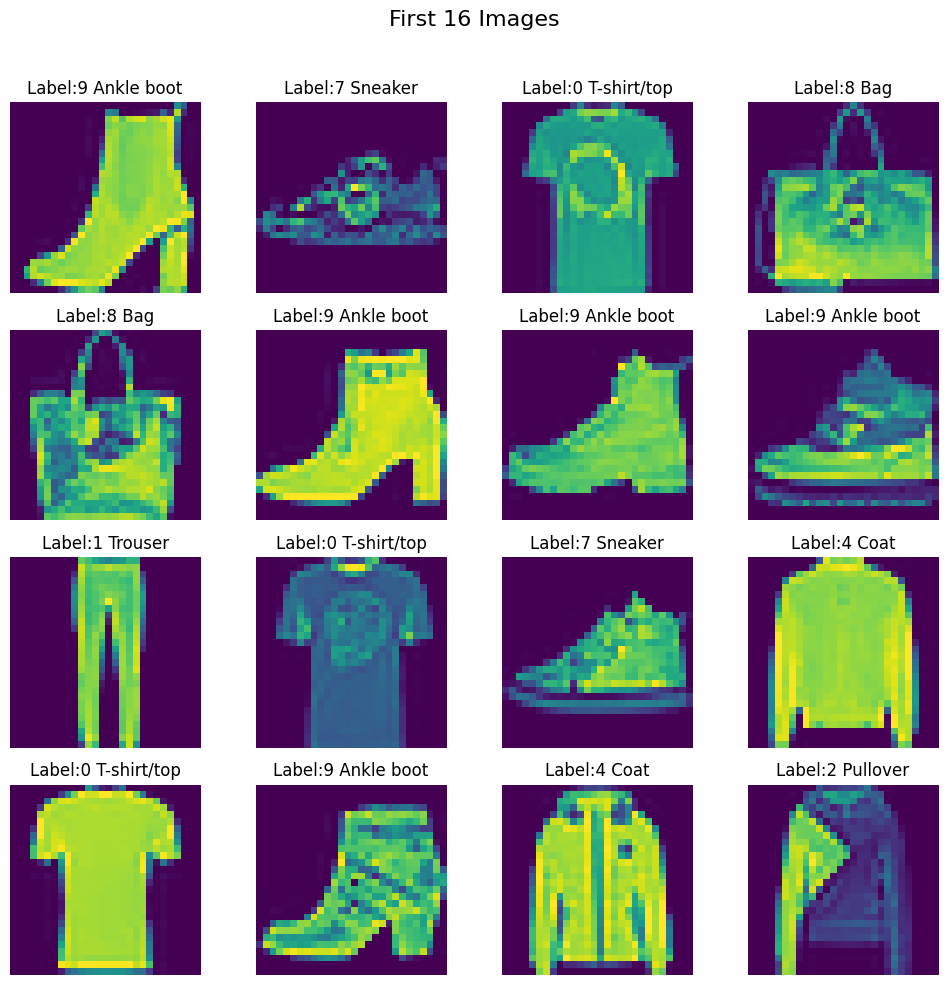

In [73]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label:{df.iloc[i, 0]} {fmnist_labels[df.iloc[i, 0]]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [8]:
df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='str', length=785)

In [10]:
df['label'].value_counts()

label
6    656
7    620
5    612
2    604
0    595
4    595
3    591
1    590
8    582
9    555
Name: count, dtype: int64

In [11]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [12]:
X

array([[  0,   0,   0, ..., 165,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(6000, 784))

In [13]:
y

array([9, 7, 0, ..., 8, 4, 8], shape=(6000,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

### Step 1 : Creating CustomDataset Class

In [23]:
class CustomDataset(Dataset):

    def __init__(self,features,lables):
        self.feature = torch.tensor(features,dtype=torch.float32)
        self.lables = torch.tensor(lables,dtype=torch.long)

    def __len__(self):
        return len(self.feature)

    def __getitem__(self,index):
        return self.feature[index] , self.lables[index]

### Step 2 : Create train_dataset object and test_dataset object

In [24]:
# train_dataset object
train_dataset = CustomDataset(X_train,y_train)

In [25]:
len(train_dataset)

4800

In [27]:
train_dataset[0:10]

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([7, 6, 7, 6, 8, 2, 0, 8, 2, 7]))

In [28]:
# test_dataset object

test_dataset = CustomDataset(X_test,y_test)

In [29]:
len(test_dataset)

1200

In [31]:
test_dataset[0:10]

(tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]),
 tensor([7, 0, 5, 6, 3, 8, 5, 4, 9, 7]))

### Step 3 : Create train and test loader

In [32]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

### Step 4 : Create ANN Model using NN class

In [43]:
X_train.shape

(4800, 784)

In [47]:
class MyANN(nn.Module):

    def __init__(self,num_features):

        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128,),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.model(x)

In [48]:
# set learning rate and epochs

epochs = 100
learning_rate = 0.1

In [49]:
model = MyANN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

### Step 5 : Training Loop

In [54]:
X_train.shape[0]/32

150.0

In [50]:
len(train_loader)

150

In [56]:
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features , batch_labels in train_loader:

        # forward pass
        outputs  = model(batch_features)

        # loss
        loss = criterion(outputs,batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grad
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch : {epoch + 1} , Loss : {avg_loss}")

Epoch : 1 , Loss : 1.3513191942373912
Epoch : 2 , Loss : 0.8018482466538747
Epoch : 3 , Loss : 0.668984552025795
Epoch : 4 , Loss : 0.5903442221879959
Epoch : 5 , Loss : 0.5410628896951676
Epoch : 6 , Loss : 0.5036374664306641
Epoch : 7 , Loss : 0.4758427345752716
Epoch : 8 , Loss : 0.46566931138436
Epoch : 9 , Loss : 0.43761301567157107
Epoch : 10 , Loss : 0.41103282193342844
Epoch : 11 , Loss : 0.3945301795999209
Epoch : 12 , Loss : 0.3721788285175959
Epoch : 13 , Loss : 0.35995224609971044
Epoch : 14 , Loss : 0.3453839495778084
Epoch : 15 , Loss : 0.3355404135088126
Epoch : 16 , Loss : 0.3052165243029594
Epoch : 17 , Loss : 0.30417691841721534
Epoch : 18 , Loss : 0.29828183226287364
Epoch : 19 , Loss : 0.27841533134380975
Epoch : 20 , Loss : 0.2719967443247636
Epoch : 21 , Loss : 0.26868305484453836
Epoch : 22 , Loss : 0.26262856473525364
Epoch : 23 , Loss : 0.2444667911529541
Epoch : 24 , Loss : 0.25010960559050244
Epoch : 25 , Loss : 0.23297001292308173
Epoch : 26 , Loss : 0.21903

### Step 6: Model Evaluation (set the model to eval mode)

The `model.eval()` method is a critical master switch in PyTorch that transitions a model into inference mode by setting its internal `training` flag to `False`. This toggle specifically modifies the behavior of layers like **Dropout**, which is deactivated to ensure deterministic outputs, and **Batch Normalization**, which is forced to use learned global statistics rather than batch-specific data. It is important to remember that `eval()` only changes how these layers function and does not stop gradient tracking; for optimal performance and memory savings during testing, it should always be paired with the `with torch.no_grad():` context manager.

In [57]:
model.eval()

MyANN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [58]:
len(test_loader)

38

In [65]:
# Evaluation code

total = 0
correct = 0

with torch.no_grad():

    for batch_features , batch_labels in test_loader:
        outputs = model(batch_features)
        _,predicted = torch.max(outputs,1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

    print(f"Accuracy :- {correct/total}")

Accuracy :- 0.8291666666666667
